In [55]:
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from scipy.sparse import csr_matrix
import scvi

sc.settings.n_jobs = 8
sc.set_figure_params(figsize=(5,5), dpi_save=300, dpi=100, frameon=False)
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams['axes.grid'] = False
%config InlineBackend.figure_format = 'retina'

In [56]:
# custom stack violin function
def stack_vln(adata:sc.AnnData, markers:list, groupby:str, layer:str, figsize:tuple=(5,8), pad:float=-0.5, **kwds):
    fig, ax = plt.subplots(len(markers),1, figsize=figsize)
    for i,g in enumerate(markers):
        sc.pl.violin(adata, keys=g, groupby=groupby,layer=layer, ax=ax[i], show=False, **kwds)
        ax[i].grid(False)
        ax[i].set_ylim((0, 1.5))
        if i+1 < len(markers):
            ax[i].set_xlabel('')
            ax[i].set_xticks([])
    fig.tight_layout(pad=pad)
    return fig, ax

In [57]:
adata_liu = sc.read_h5ad('./Results_h5ad/07_neuron_liu_dev_sub.h5ad')
adata_early = sc.read_h5ad('Results_h5ad/05_Neuron_p0_anno.h5ad')

In [58]:
intersect_genes = np.intersect1d(adata_liu.var_names, adata_early.var_names)

In [59]:
adata_liu.X = adata_liu.layers['counts'].copy()
adata_early.X = adata_early.layers['umi'].copy()

for ad in [adata_liu, adata_early]:
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    sc.pp.scale(ad)

/Users/pax/miniconda3/envs/vestibular/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/pax/miniconda3/envs/vestibular/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [60]:
ct_liu_data = adata_liu.to_df().assign(ct=adata_liu.obs.leiden_sub.values).groupby('ct', observed=True).mean()[intersect_genes]
ct_my_data = adata_early.to_df().assign(ct=adata_early.obs.my_cluster.values).groupby('ct', observed=True).mean()[intersect_genes]

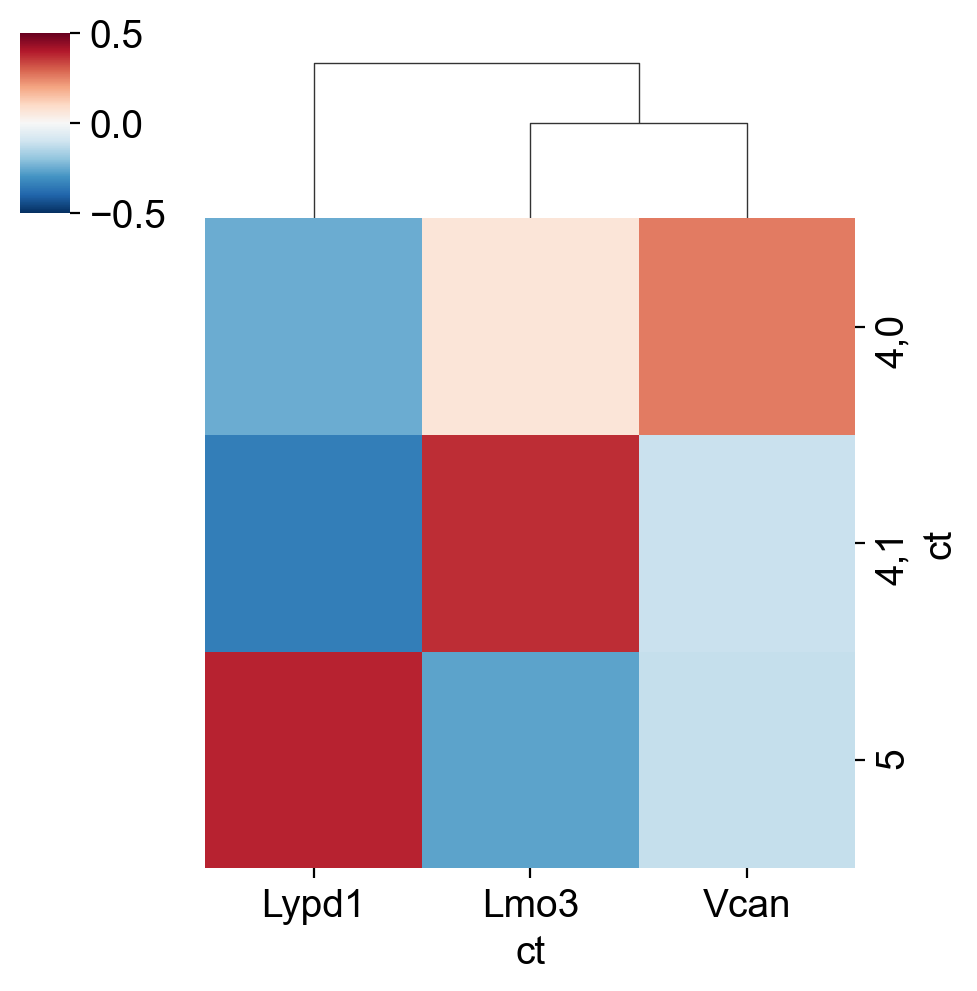

In [61]:
ctx = pd.concat([ct_liu_data,ct_my_data]).T.corr()
sns.clustermap(ctx.loc[ct_liu_data.index, ct_my_data.index], cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5, figsize=(5,5), row_cluster=False)
plt.savefig('./figures/09_e13.5_p0_corr.pdf', bbox_inches='tight', dpi=300)